In [272]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import string
import os
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import shutil
import gc

In [273]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Hyperparameters

EMBEDDING_DIMENSION = 32
LR = 0.001
EPOCHS = 10
BATCH_SIZE = 128
TEACHER_FORCING = False

## 3 Sequence-to-Sequence Modeling

### Data Preprocessing

In [275]:
data = pd.read_csv('topical_chat_pairs.csv', sep='\t')
data.head()

,id,conversation_id,message,answer
0,0,1,Are you a fan of Google or Microsoft?,Both are excellent technology they are helpfu...
1,1,1,Both are excellent technology they are helpfu...,"I'm not a huge fan of Google, but I use it a..."
2,2,1,"I'm not a huge fan of Google, but I use it a...",Google provides online related services and p...
3,3,1,Google provides online related services and p...,"Yeah, their services are good. I'm just not a..."
4,4,1,"Yeah, their services are good. I'm just not a...",Google is leading the alphabet subsidiary and...


In [276]:
# Create vocabulary from the dataset

word2index = {}
index2word = {}

word2index['<SOS>'] = 0
word2index['<EOS>'] = 1
word2index['<PAD>'] = 2
index2word[0] = '<SOS>'
index2word[1] = '<EOS>'
index2word[2] = '<PAD>'

In [277]:
# get the unique words in the dataset

lenghts = []
unique_words = set()
for text in data['message']:
    tokens = word_tokenize(text.strip().lower())
    lenghts.append(len(tokens))
    for word in tokens:
        unique_words.add(word)
for text in data['answer']:
    tokens = word_tokenize(text.strip().lower())
    lenghts.append(len(tokens))
    for word in tokens:
        unique_words.add(word)
print(f'Number of unique words: {len(unique_words)}')
print(f'{sorted(list(unique_words))[:5]}')
AVERAGE_LENGTH = round(np.mean(lenghts))
print(f'Average length of sentences: {AVERAGE_LENGTH}')

Number of unique words: 41112
['!', '#', '$', '%', '&']
Average length of sentences: 23


In [278]:
# add the unique words to the vocabulary
# and assign them an index

for word in unique_words:
    index = len(word2index)
    word2index[word] = index
    index2word[index] = word
print(f'Number of words in vocabulary: {len(word2index)}')

Number of words in vocabulary: 41115


In [279]:
# collate function for DataLoader
# Prepends <SOS> and appends <EOS> to each message and answer
# Pads the sequences to a fixed length AVERAGE_LENGTH + 2
# where AVERAGE_LENGTH is the average length of the sentences in the dataset
# and converts them to tensors

def collate_fn(batch):
    messages, answers = zip(*batch)
    preprocessed_messages = []
    for message in messages:
        message = word_tokenize(message.strip().lower())
        preprocessed_message = []
        preprocessed_message.append(word2index['<SOS>'])
        for word in message[:AVERAGE_LENGTH]:
            preprocessed_message.append(word2index[word])
        preprocessed_message.append(word2index['<EOS>'])
        if len(preprocessed_message) < AVERAGE_LENGTH + 2:  # +2 for <SOS> and <EOS>
            preprocessed_message += [word2index['<PAD>']] * (AVERAGE_LENGTH + 2 - len(preprocessed_message))
        preprocessed_messages.append(preprocessed_message)

    max_length = max(len(text) for text in answers)
    preprocessed_answers = []
    for answer in answers:
        answer = word_tokenize(answer.strip().lower())
        preprocessed_answer = []
        preprocessed_answer.append(word2index['<SOS>'])
        for word in answer[:AVERAGE_LENGTH]:
            preprocessed_answer.append(word2index[word])
        preprocessed_answer.append(word2index['<EOS>'])
        if len(preprocessed_answer) < AVERAGE_LENGTH + 2:  # +2 for <SOS> and <EOS>
            preprocessed_answer += [word2index['<PAD>']] * (AVERAGE_LENGTH + 2 - len(preprocessed_answer))
        preprocessed_answers.append(preprocessed_answer)

    preprocessed_messages = torch.tensor(preprocessed_messages, dtype=torch.long)
    preprocessed_answers = torch.tensor(preprocessed_answers, dtype=torch.long)
    return preprocessed_messages, preprocessed_answers

In [280]:
# The Dataset class for the sequence data

class SequenceDataset(Dataset):
    def __init__(self, messages, answers):
        if len(messages) != len(answers):
            raise ValueError("Messages and answers must have the same length.")
        if not isinstance(messages, list) or not isinstance(answers, list):
            try:
                messages = messages.tolist()
                answers = answers.tolist()
            except AttributeError:
                raise TypeError("Messages and answers must be convertible to lists.")
        self.messages = messages
        self.answers = answers

    def __len__(self):
        return len(self.messages)

    def __getitem__(self, idx):
        return self.messages[idx], self.answers[idx]

In [281]:
dataset = SequenceDataset(data['message'], data['answer'])

In [282]:
# Create DataLoaders for training, validation, and testing with a 0.8/0.1/0.1 split

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, drop_last=True)

In [283]:
# verify the DataLoader by printing the shapes of the first batch
# and the first 4 messages and answers

for messages, answers in train_loader:
    print(f'Messages batch shape: {messages.shape}')
    print(f'Answers batch shape: {answers.shape}')
    for i in range(4):
        print(f'Message {i}: {messages[i]}')
        print(f'Answer {i}: {answers[i]}')
    break

Messages batch shape: torch.Size([128, 25])
Answers batch shape: torch.Size([128, 25])
Message 0: tensor([    0, 30094, 27275,  4186,  2766, 29976,  8395, 36221, 33046, 17125,
        37316, 13192, 16477,     1,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2])
Answer 0: tensor([    0, 25526,  1834, 32761, 38386, 31482, 19713, 35011, 39811, 15129,
        22233, 16477,  8371, 10302, 24452, 37316, 26785, 31270, 21750,  8510,
        29537, 25526,  8395, 28927,     1])
Message 1: tensor([    0,  9695, 29537, 11349, 17125,  8395, 35337,  2070, 22771,  7869,
        18888, 34979,  2991, 28494, 12935, 10958, 20466, 29365, 21916,  7869,
        18888, 34979, 36199, 24312,     1])
Answer 1: tensor([    0, 30094, 12026, 11349, 25526, 12482, 24452, 17399,  6067, 36199,
        31100, 24450, 23584, 19535, 25526, 31769,  5999, 25526, 34717, 32651,
          407, 36199,  9428,  5501,     1])
Message 2: tensor([    0, 34536,  1834, 24445, 30094, 27275,  4186, 338

### Model

In [284]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input):
        embedded = self.embedding(input)
        # h0 = torch.zeros(1, BATCH_SIZE, self.hidden_size, device=embedded.device)
        h0 = torch.zeros(1, input.shape[0], self.hidden_size, device=embedded.device) # use input.shape[0] to be able to handle inference with batch size 1
        _, output = self.gru(embedded, h0)
        return output

In [285]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        embedded = self.relu(embedded)
        embedded = embedded.unsqueeze(0)
        output, last_hidden = self.gru(embedded, hidden)
        output = self.linear(output)
        output = self.softmax(output)
        output = output.squeeze(0)
        return output, last_hidden

In [286]:
encoder = EncoderRNN(len(word2index), EMBEDDING_DIMENSION).to(DEVICE)
decoder = DecoderRNN(EMBEDDING_DIMENSION, len(word2index)).to(DEVICE)

encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=LR)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=LR)
criterion = nn.NLLLoss(ignore_index=word2index['<PAD>'])

if not os.path.exists('models'):
    os.makedirs('models')
encoder_path = 'models/encoder.pth'
decoder_path = 'models/decoder.pth'

In [287]:
# top k sampling function
# returns the already sampled tokens

def topk_sample(output, k=5):
    values, indices = torch.topk(output, k, dim=1)
    probabilities = torch.nn.functional.softmax(values, dim=1).to(DEVICE)
    sampled_indices = torch.multinomial(probabilities, num_samples=1).to(DEVICE)
    sampled_tokens = []
    for i, idx in enumerate(sampled_indices):
        sampled_tokens.append(indices[i][idx].item())
    sampled_tokens = torch.tensor(sampled_tokens).to(DEVICE)
    return sampled_tokens

In [288]:
# matplotlib plotting function for training and validation loss

def plot_loss(train_losses, val_losses):
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [289]:
# calculate validation loss

def validate_model(encoder, decoder, val_loader, criterion, k=5, device=DEVICE):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        val_loader = tqdm(val_loader, desc="Validating")
        for i, (messages, answers) in enumerate(val_loader):
            messages = messages.to(device)
            answers = answers.to(device)

            encoder_output = encoder(messages)
            last_hidden = encoder_output
            decoder_input = answers[:, 0]  # Start with the first token of the answer
            batch_loss = 0.0
            for j in range(1, answers.size(1)):
                output, last_hidden = decoder(decoder_input, last_hidden)
                loss = criterion(output, answers[:, j])
                batch_loss += loss.item()
                decoder_input = topk_sample(output, k=k) # Use the predicted token as the next input
            total_loss += batch_loss / answers.size(1)
    avg_loss = total_loss / len(val_loader)
    return avg_loss

In [290]:
def train(encoder, decoder, train_loader, val_loader, criterion, encoder_optimizer, decoder_optimizer, epochs, device, k=5, teacher_forcing=False):
    writer = SummaryWriter()
    average_training_loss_per_epoch = []
    validation_loss_per_epoch = []
    min_validation_loss = float('inf')
    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        total_loss = 0.0
        train_loader = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')
        for i, (messages, answers) in enumerate(train_loader):
            messages, answers = messages.to(device), answers.to(device)
            encoder_optimizer.zero_grad()
            decoder_optimizer.zero_grad()

            encoder_output = encoder(messages)
            last_hidden = encoder_output
            decoder_input = answers[:, 0]  # Start with the <SOS> token
            batch_loss = 0
            for j in range(1, answers.size(1)):
                if teacher_forcing:
                    # witch teacher forcing, use the ground truth token as the next input
                    output, last_hidden = decoder(answers[:, j-1], last_hidden)
                    loss = criterion(output, answers[:, j])
                    batch_loss += loss
                else:
                    # without teacher forcing, use the predicted token as the next input
                    output, last_hidden = decoder(decoder_input, last_hidden)
                    loss = criterion(output, answers[:, j])
                    batch_loss += loss
                    decoder_input = topk_sample(output, k=k)  # Use the top-k sampled indices as the next input
            batch_loss = batch_loss / answers.size(1)
            batch_loss.backward()
            encoder_optimizer.step()
            decoder_optimizer.step()

            total_loss += batch_loss.item()
            train_loader.set_postfix({"loss": total_loss / (i + 1)})
        validation_loss = validate_model(encoder, decoder, val_loader, criterion, k, device)

        # for matplotlib plotting
        average_training_loss_per_epoch.append(total_loss / len(train_loader))
        validation_loss_per_epoch.append(validation_loss)

        # save the model if validation loss improves
        if validation_loss < min_validation_loss:
            min_validation_loss = validation_loss
            torch.save(encoder.state_dict(), encoder_path)
            torch.save(decoder.state_dict(), decoder_path)
            print(f"Validation loss improved to {min_validation_loss:.4f}, models saved.")

        writer.add_scalar('Training Loss', total_loss / len(train_loader), epoch)
        writer.add_scalar('Validation Loss', validation_loss, epoch)
        writer.flush()
    plot_loss(average_training_loss_per_epoch, validation_loss_per_epoch)
    writer.close()
        

Validating: 100%|██████████| 140/140 [00:34<00:00,  4.09it/s]


Validation loss improved to 5.7547, models saved.


Validating: 100%|██████████| 140/140 [00:32<00:00,  4.33it/s]


Validation loss improved to 5.6696, models saved.


Validating: 100%|██████████| 140/140 [00:31<00:00,  4.46it/s]


...

Validation loss improved to 5.6221, models saved.


Validating: 100%|██████████| 140/140 [00:31<00:00,  4.43it/s]


Validation loss improved to 5.6172, models saved.


Validating: 100%|██████████| 140/140 [00:31<00:00,  4.49it/s]

Validation loss improved to 5.6135, models saved.


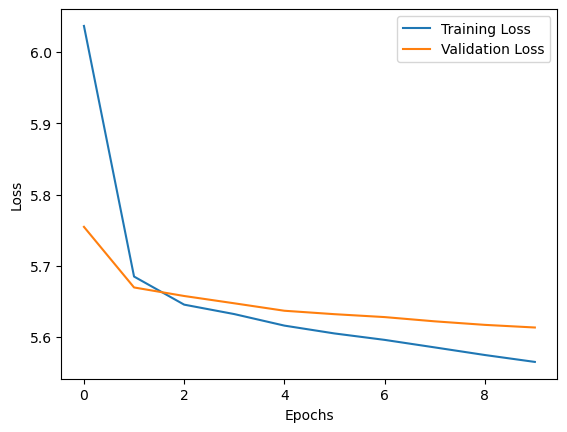

In [291]:
train(
    encoder=encoder,
    decoder=decoder,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    encoder_optimizer=encoder_optimizer,
    decoder_optimizer=decoder_optimizer,
    epochs=EPOCHS,
    device=DEVICE,
    k=5,
    teacher_forcing=TEACHER_FORCING
)

In [292]:
# load the best saved model weights for testing

encoder.load_state_dict(torch.load(encoder_path))
decoder.load_state_dict(torch.load(decoder_path))

<All keys matched successfully>

In [293]:
def print_test_samples(encoder, decoder, test_loader, n=5, k=5, t=AVERAGE_LENGTH, device=DEVICE):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    random_indices = np.random.choice(np.arange(len(test_loader)), size=n, replace=False)
    print(f'Randomly selected indices for test samples: {sorted(random_indices)}')

    with torch.no_grad():
        for i, (messages, answers) in enumerate(test_loader):
            if i not in random_indices:
                continue
            print(f'\nSample {i}:')
            random_message_index = np.random.choice(np.arange(len(messages)), size=1, replace=False).item()
            random_message = messages[random_message_index].to(device)
            print(f"Message: {' '.join([index2word[index.to('cpu').item()] for index in random_message if index not in [0, 1, 2]])}")

            messages = messages.to(device)
            answer = []

            encoder_output = encoder(random_message.unsqueeze(0))  # Add batch dimension
            last_hidden = encoder_output
            decoder_input = torch.tensor([word2index['<SOS>']]).to(device)  # Start with the first token of the answer
            for j in range(1, t):
                output, last_hidden = decoder(decoder_input, last_hidden)
                decoder_input = topk_sample(output, k=k)
                word = index2word[decoder_input.item()]
                if word == '<EOS>':
                    break
                answer.append(word)
            print(f'Predicted answer: {" ".join(answer)}')

In [294]:
print_test_samples(encoder, decoder, test_loader, n=5, t=AVERAGE_LENGTH, device=DEVICE)

Randomly selected indices for test samples: [34, 54, 97, 132, 137]

Sample 34:
Message: thats a great thing i guess , the internet is neccesary now i cant imagine my life without it
Predicted answer: i is . . that that , . i a the .

Sample 54:
Message: wow ! that is so much bandwidth , i think netflix took up the other half ! lol .
Predicted answer: i , , i i that . , i i . , the the

Sample 97:
Message: i bet it 's due to all the carjacking that takes place , but why a flame thrower and not some other device
Predicted answer: yeah 's , is that . that the that that . . a .

Sample 132:
Message: your right , i agree ! no written rule at all . an engineer in his lifetime will make more than the lifetime
Predicted answer: i 's a , . i , , that . , , . a the .

Sample 137:
Message: what do you consider a more affluent country to be ?
Predicted answer: yes i i , . , . i
